In [1]:
import os
import cv2
import math
from glob import glob
from pathlib import Path

# Parameters
base_magnification = 36000
patch_size = 128
input_root = 'MultiMag'      # e.g. './raw_images'
output_root = 'MultiMag_Patches'   # e.g. './patches'

# Make output root
os.makedirs(output_root, exist_ok=True)

# Process each magnification
for mag_folder in os.listdir(input_root):
    mag_path = os.path.join(input_root, mag_folder)
    if not os.path.isdir(mag_path): continue

    mag = int(mag_folder)
    scale = base_magnification / mag

    for img_path in glob(f"{mag_path}/*"):
        img_name = Path(img_path).stem
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: couldn't read {img_path}")
            continue

        # Rescale if needed
        if scale != 1.0:
            new_size = (int(img.shape[1] * scale), int(img.shape[0] * scale))
            img = cv2.resize(img, new_size, interpolation=cv2.INTER_LINEAR)

        h, w = img.shape[:2]
        patch_id = 0
        for y in range(0, h - patch_size + 1, patch_size):
            for x in range(0, w - patch_size + 1, patch_size):
                patch = img[y:y+patch_size, x:x+patch_size]
                patch_name = f"{mag}_{img_name}_patch{patch_id}.png"
                patch_path = os.path.join(output_root, patch_name)
                cv2.imwrite(patch_path, patch)
                patch_id += 1


In [7]:
import os
import json
import random

DATASET_DIR = "MultiMag_Labelled"
OUTPUT_JSON = "dataset_split.json"
# Define your six classes
classes = ["background", "lowfill", "multilayer", "single-hexagonal", "single-square"]

# Use an 80/10/10 split for train/val/test
split_ratio = {"train": 0.8, "val": 0.1, "test": 0.1}
data_split = {"train": {}, "val": {}, "test": {}}

for cls in classes:
    class_dir = os.path.join(DATASET_DIR, cls)
    if not os.path.exists(class_dir):
        print(f"Class folder {cls} not found. Skipping.")
        continue
    images = os.listdir(class_dir)
    random.shuffle(images)
    n = len(images)
    n_train = int(n * split_ratio["train"])
    n_val = int(n * split_ratio["val"])
    train_files = images[:n_train]
    val_files = images[n_train:n_train+n_val]
    test_files = images[n_train+n_val:]
    data_split["train"][cls] = [os.path.join(class_dir, f) for f in train_files]
    data_split["val"][cls] = [os.path.join(class_dir, f) for f in val_files]
    data_split["test"][cls] = [os.path.join(class_dir, f) for f in test_files]

with open(OUTPUT_JSON, "w") as f:
    json.dump(data_split, f, indent=4)
print("JSON split saved.")


JSON split saved.


In [15]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [13]:
import os
import json
import shutil
import numpy as np
from PIL import Image

with open("dataset_split.json", "r") as f:
    data_split = json.load(f)

OUTPUT_DIRS = {
    "train": {"images": "./train_data4/images", "masks": "./train_data4/masks"},
    "val": {"images": "./val_data4/images", "masks": "./val_data4/masks"},
    "test": {"images": "./test_data4/images", "masks": "./test_data4/masks"}
}
for split in OUTPUT_DIRS:
    os.makedirs(OUTPUT_DIRS[split]["images"], exist_ok=True)
    os.makedirs(OUTPUT_DIRS[split]["masks"], exist_ok=True)

# Same class order as before
classes = ["background", "lowfill", "multilayer", "single-hexagonal", "single-square"]

for split, split_data in data_split.items():
    for cls in classes:
        for img_path in split_data.get(cls, []):
            img_name = os.path.basename(img_path)
            dest_img_path = os.path.join(OUTPUT_DIRS[split]["images"], img_name)
            shutil.copy(img_path, dest_img_path)
            # Create a mask of size 128x128 with class index
            mask = np.full((128, 128), classes.index(cls), dtype=np.uint8)
            mask_name = os.path.splitext(img_name)[0] + "_mask.png"
            mask_path = os.path.join(OUTPUT_DIRS[split]["masks"], mask_name)
            Image.fromarray(mask).save(mask_path)

print("Dataset prepared with train/val/test splits and masks.")


Dataset prepared with train/val/test splits and masks.


In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- Parameters & Paths ---
IMG_SIZE = (128, 128)
BATCH_SIZE = 8
NUM_CLASSES = 5  # background, lowfill, multilayer, single-hexagonal, single-square
EPOCHS = 20

TRAIN_IMAGES_DIR = './train_data4/images'
TRAIN_MASKS_DIR = './train_data4/masks'
VAL_IMAGES_DIR   = './val_data4/images'
VAL_MASKS_DIR    = './val_data4/masks'

# --- Data Loading ---
def load_image(path, is_mask=False):
    img = tf.io.read_file(path)
    if is_mask:
        img = tf.image.decode_png(img, channels=1)
        img = tf.cast(img, tf.uint8)
    else:
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    return img

def load_data(image_path, mask_path):
    image = load_image(image_path, is_mask=False)
    mask  = load_image(mask_path, is_mask=True)
    mask  = tf.squeeze(mask, axis=-1)
    mask  = tf.one_hot(tf.cast(mask, tf.int32), NUM_CLASSES)
    return image, mask

def get_dataset(images_dir, masks_dir):
    image_files = sorted([os.path.join(images_dir, fname) for fname in os.listdir(images_dir) if fname.endswith(('.png','.jpg','.jpeg'))])
    mask_files  = sorted([os.path.join(masks_dir, fname) for fname in os.listdir(masks_dir) if fname.endswith('.png')])
    dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
    dataset = dataset.map(load_data, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

train_ds = get_dataset(TRAIN_IMAGES_DIR, TRAIN_MASKS_DIR)
val_ds   = get_dataset(VAL_IMAGES_DIR, VAL_MASKS_DIR)

# --- U-Net Model ---
def unet_model(input_size=(128, 128, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(input_size)
    # Encoder
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)

    c4 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2,2))(c4)

    # Bridge
    c5 = layers.Conv2D(1024, (3,3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3,3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.UpSampling2D((2,2))(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D((2,2))(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c7)

    u8 = layers.UpSampling2D((2,2))(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c8)

    u9 = layers.UpSampling2D((2,2))(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(num_classes, (1,1), activation='softmax')(c9)
    return models.Model(inputs, outputs)

model = unet_model(input_size=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# --- Training ---
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 128, 128, 64  36928       ['conv2d[0][0]']                 
                                )                                                             

KeyboardInterrupt: 

In [8]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pytorch_lightning as pl
import matplotlib.pyplot as plt

# ----- Dataset -----
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        self.mask_files = sorted([os.path.join(masks_dir, f) for f in os.listdir(masks_dir) if f.lower().endswith('.png')])
        self.transform = transform

    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("RGB")
        mask  = Image.open(self.mask_files[idx]).convert("L")
        if self.transform:
            image = self.transform(image)
            # For masks, use nearest neighbor interpolation and then convert to tensor
            mask = transforms.Resize(image.shape[1:], interpolation=Image.NEAREST)(mask)
        # Convert mask to tensor of type long (assumes pixel values represent class indices)
        mask = torch.from_numpy(np.array(mask)).long()
        return image, mask

# ----- Lightning DataModule -----
class SegDataModule(pl.LightningDataModule):
    def __init__(self, train_img_dir, train_mask_dir, val_img_dir, val_mask_dir, batch_size=8, num_workers=4, img_size=(128,128)):
        super().__init__()
        self.train_img_dir = train_img_dir
        self.train_mask_dir = train_mask_dir
        self.val_img_dir = val_img_dir
        self.val_mask_dir = val_mask_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.img_size = img_size

    def setup(self, stage=None):
        transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor()
        ])
        self.train_dataset = SegmentationDataset(self.train_img_dir, self.train_mask_dir, transform=transform)
        self.val_dataset   = SegmentationDataset(self.val_img_dir, self.val_mask_dir, transform=transform)
    
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, num_workers=self.num_workers, shuffle=True)
    
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, num_workers=self.num_workers)

# ----- U-Net Model -----
class UNet(pl.LightningModule):
    def __init__(self, num_classes=5, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.num_classes = num_classes
        self.lr = lr
        # Encoder
        self.enc1 = self.conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        # Bridge
        self.center = self.conv_block(512, 1024)
        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64)
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)
        e4 = self.enc4(p3)
        p4 = self.pool4(e4)
        center = self.center(p4)
        d4 = self.up4(center)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.out_conv(d1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log("val_loss", loss)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# ----- Inference on Large Images via Tiling -----
def predict_large_image(model, image_path, tile_size=(128,128), device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    model.to(device)
    orig_img = Image.open(image_path).convert("RGB")
    width, height = orig_img.size
    # Pad image to a multiple of tile size
    new_w = ((width - 1) // tile_size[0] + 1) * tile_size[0]
    new_h = ((height - 1) // tile_size[1] + 1) * tile_size[1]
    padded_img = Image.new("RGB", (new_w, new_h))
    padded_img.paste(orig_img, (0, 0))
    transform = transforms.ToTensor()
    padded_tensor = transform(padded_img).unsqueeze(0).to(device)  # [1,3,H,W]
    _, _, H, W = padded_tensor.shape
    result_mask = torch.zeros((H, W), dtype=torch.long, device=device)
    with torch.no_grad():
        for i in range(0, H, tile_size[1]):
            for j in range(0, W, tile_size[0]):
                tile = padded_tensor[:, :, i:i+tile_size[1], j:j+tile_size[0]]
                logits = model(tile)
                preds = torch.argmax(F.softmax(logits, dim=1), dim=1)
                result_mask[i:i+tile_size[1], j:j+tile_size[0]] = preds[0]
    return result_mask[:height, :width].cpu().numpy()

# ----- Main Training & Inference -----
if __name__ == "__main__":
    # Directories for train and validation sets
    train_img_dir = "./train_data4/images"
    train_mask_dir = "./train_data4/masks"
    val_img_dir   = "./val_data4/images"
    val_mask_dir  = "./val_data4/masks"
    
    dm = SegDataModule(train_img_dir, train_mask_dir, val_img_dir, val_mask_dir, batch_size=8)
    dm.setup()
    
    model = UNet(num_classes=5, lr=1e-3)
    
    trainer = pl.Trainer(max_epochs=20)
    trainer.fit(model, dm)
    
    # Inference on a larger image
    large_image_path = "36kImages/36000 x 1749 Ceta.jpeg"  # Update with valid path.
    if os.path.exists(large_image_path):
        seg_mask = predict_large_image(model, large_image_path)
        plt.figure(figsize=(8,8))
        plt.imshow(seg_mask, cmap="jet")
        plt.title("Predicted Segmentation")
        plt.axis("off")
        plt.show()
    else:
        print("Large test image not found. Update 'large_image_path' accordingly.")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name     | Type            | Params
----------------------------------------------
0  | enc1     | Sequential      | 38.7 K
1  | pool1    | MaxPool2d       | 0     
2  | enc2     | Sequential      | 221 K 
3  | pool2    | MaxPool2d       | 0     
4  | enc3     | Sequential      | 885 K 
5  | pool3    | MaxPool2d       | 0     
6  | enc4     | Sequential      | 3.5 M 
7  | pool4    | MaxPool2d       | 0     
8  | center   | Sequential      | 14.2 M
9  | up4      | ConvTranspose2d | 2.1 M 
10 | dec4     | Sequential      | 7.1 M 
11 | up3      | ConvTranspose2d | 524 K 
12 | dec3     | Sequential      | 1.8 M 
13 | up2      | ConvTranspose2d | 131 K 
14 | dec2     | Sequential      | 442 K 
15 | up1      | ConvTranspose2d | 32.8 K
16 | dec1     | Sequential      | 110 K 
17 | out_conv | Conv

Sanity Checking: 0it [00:00, ?it/s]

RuntimeError: DataLoader worker (pid(s) 75472, 53660, 101172, 77668) exited unexpectedly

In [1]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pytorch_lightning as pl
import matplotlib.pyplot as plt

# ----- Dataset -----
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        self.mask_files = sorted([os.path.join(masks_dir, f) for f in os.listdir(masks_dir) if f.lower().endswith('.png')])
        self.transform = transform

    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("RGB")
        mask  = Image.open(self.mask_files[idx]).convert("L")
        if self.transform:
            image = self.transform(image)
            # For masks, use nearest neighbor interpolation and then convert to tensor
            mask = transforms.Resize(image.shape[1:], interpolation=Image.NEAREST)(mask)
        # Convert mask to tensor of type long (assumes pixel values represent class indices)
        mask = torch.from_numpy(np.array(mask)).long()
        return image, mask

# ----- Lightning DataModule -----
class SegDataModule(pl.LightningDataModule):
    def __init__(self, train_img_dir, train_mask_dir, val_img_dir, val_mask_dir, batch_size=8, num_workers=4, img_size=(128,128)):
        super().__init__()
        self.train_img_dir = train_img_dir
        self.train_mask_dir = train_mask_dir
        self.val_img_dir = val_img_dir
        self.val_mask_dir = val_mask_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.img_size = img_size

    def setup(self, stage=None):
        transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor()
        ])
        self.train_dataset = SegmentationDataset(self.train_img_dir, self.train_mask_dir, transform=transform)
        self.val_dataset   = SegmentationDataset(self.val_img_dir, self.val_mask_dir, transform=transform)
    
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, num_workers=self.num_workers, shuffle=True)
    
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, num_workers=self.num_workers)

# ----- U-Net Model -----
class UNet(pl.LightningModule):
    def __init__(self, num_classes=5, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.num_classes = num_classes
        self.lr = lr
        # Encoder
        self.enc1 = self.conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        # Bridge
        self.center = self.conv_block(512, 1024)
        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64)
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)
        e4 = self.enc4(p3)
        p4 = self.pool4(e4)
        center = self.center(p4)
        d4 = self.up4(center)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.out_conv(d1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log("val_loss", loss)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# ----- Inference on Large Images via Tiling -----
def predict_large_image(model, image_path, tile_size=(128,128), device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    model.to(device)
    orig_img = Image.open(image_path).convert("RGB")
    width, height = orig_img.size
    # Pad image to a multiple of tile size
    new_w = ((width - 1) // tile_size[0] + 1) * tile_size[0]
    new_h = ((height - 1) // tile_size[1] + 1) * tile_size[1]
    padded_img = Image.new("RGB", (new_w, new_h))
    padded_img.paste(orig_img, (0, 0))
    transform = transforms.ToTensor()
    padded_tensor = transform(padded_img).unsqueeze(0).to(device)  # [1,3,H,W]
    _, _, H, W = padded_tensor.shape
    result_mask = torch.zeros((H, W), dtype=torch.long, device=device)
    with torch.no_grad():
        for i in range(0, H, tile_size[1]):
            for j in range(0, W, tile_size[0]):
                tile = padded_tensor[:, :, i:i+tile_size[1], j:j+tile_size[0]]
                logits = model(tile)
                preds = torch.argmax(F.softmax(logits, dim=1), dim=1)
                result_mask[i:i+tile_size[1], j:j+tile_size[0]] = preds[0]
    return result_mask[:height, :width].cpu().numpy()

# ----- Main Training & Inference -----
if __name__ == "__main__":
    # Directories for train and validation sets
    train_img_dir = "./train_data4/images"
    train_mask_dir = "./train_data4/masks"
    val_img_dir   = "./val_data4/images"
    val_mask_dir  = "./val_data4/masks"
    
    dm = SegDataModule(train_img_dir, train_mask_dir, val_img_dir, val_mask_dir, batch_size=8)
    dm.setup()
    
    model = UNet(num_classes=5, lr=1e-3)
    
    trainer = pl.Trainer(max_epochs=20,     accelerator="gpu" if torch.cuda.is_available() else "cpu")
    trainer.fit(model, dm)
    
    # Inference on a larger image
    large_image_path = "./test_data4/images/example_large.png"  # Update with valid path.
    if os.path.exists(large_image_path):
        seg_mask = predict_large_image(model, large_image_path)
        plt.figure(figsize=(8,8))
        plt.imshow(seg_mask, cmap="jet")
        plt.title("Predicted Segmentation")
        plt.axis("off")
        plt.show()
    else:
        print("Large test image not found. Update 'large_image_path' accordingly.")


c:\Users\alexg\anaconda3\lib\site-packages\transformers\utils\generic.py:482: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\alexg\anaconda3\lib\site-packages\transformers\utils\generic.py:339: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\alexg\anaconda3\lib\site-packages\transformers\utils\generic.py:339: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\alexg\anaconda3\lib\site-packages\transformers\utils\generic.py:339: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._regist

Sanity Checking: 0it [00:00, ?it/s]

RuntimeError: DataLoader worker (pid(s) 44700, 42620, 22280, 44164) exited unexpectedly

In [6]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
from torchvision.transforms.functional import hflip, rotate, adjust_brightness
from torch.optim.lr_scheduler import CosineAnnealingLR
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
import wandb

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, augment=False):
        self.image_paths = sorted(os.listdir(image_dir))
        self.mask_paths = sorted(os.listdir(mask_dir))
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_paths[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_paths[idx])
        
        image = Image.open(img_path).convert("RGB").resize((128, 128), resample=Image.BILINEAR)
        mask = Image.open(mask_path).resize((128, 128), resample=Image.NEAREST)

        mask = mask.resize((128, 128), resample=Image.NEAREST)  # Resize to match model output

        # Convert mask to numpy array for transformations
        mask = np.array(mask, dtype=np.int64)

        if self.augment:
            # Apply augmentations
            if np.random.rand() > 0.5:
                image = hflip(image)
                mask = np.fliplr(mask)
            if np.random.rand() > 0.5:
                angle = np.random.uniform(-30, 30)
                image = rotate(image, angle)
                mask = np.array(Image.fromarray(mask).rotate(angle, resample=Image.NEAREST))
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.7, 1.3)
                image = adjust_brightness(image, brightness_factor)

        if self.transform:
            image = self.transform(image)
            mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

class PixelSegmentationCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(PixelSegmentationCNN, self).__init__()
        
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2)  # Downsample
        
        # Decoder
        self.dec3 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, num_classes, kernel_size=1)  # Predict per-pixel class scores
        )
        
        # 1x1 Convolutions for Skip Connections
        self.conv1x1_3 = nn.Conv2d(128, 128, kernel_size=1)  # for x2
        self.conv1x1_2 = nn.Conv2d(64, 64, kernel_size=1)    # for x1
        
        # Upsampling
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
    
    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)        # Shape: (batch, 64, 128, 128)
        x = self.pool(x1)        # Shape: (batch, 64, 64, 64)
        x2 = self.enc2(x)        # Shape: (batch, 128, 64, 64)
        x = self.pool(x2)        # Shape: (batch, 128, 32, 32)
        x3 = self.enc3(x)        # Shape: (batch, 256, 32, 32)
        
        # Decoder with skip connections
        x = self.upsample(x3)    # Shape: (batch, 256, 64, 64)
        x = self.dec3(x)         # Shape: (batch, 128, 64, 64)
        x = x + self.conv1x1_3(x2)  # Skip connection from x2
        
        x = self.upsample(x)     # Shape: (batch, 128, 128, 128)
        x = self.dec2(x)         # Shape: (batch, 64, 128, 128)
        x = x + self.conv1x1_2(x1)  # Skip connection from x1
        
        x = self.dec1(x)         # Final output: (batch, num_classes, 128, 128)
        return x

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Initialize datasets and data loaders
train_dataset = SegmentationDataset("./train_data4/images", "./train_data4/masks", transform=transform)
val_dataset = SegmentationDataset("./val_data4/images", "./val_data4/masks", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Define the segmentation model
class SegmentationModel(pl.LightningModule):
    def __init__(self, num_classes=5):
        super(SegmentationModel, self).__init__()
        self.model = PixelSegmentationCNN(num_classes=num_classes)
        self.criterion = nn.CrossEntropyLoss()  # Pixel-wise loss

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, masks)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, masks)
        self.log("val_loss", loss)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=1e-4, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

# Train the model
wandb_logger = WandbLogger(project="Pixel_Segmentation")

model = SegmentationModel(num_classes=5)

trainer = pl.Trainer(
    max_epochs=20,
    devices=1 if torch.cuda.is_available() else 0,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    logger=wandb_logger
)

trainer.fit(model, train_loader, val_loader)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                 | Params
---------------------------------------------------
0 | model     | PixelSegmentationCNN | 1.6 M 
1 | criterion | CrossEntropyLoss     | 0     
---------------------------------------------------
1.6 M     Trainable params
0         Non-trainable params
1.6 M     Total params
6.298     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

c:\Users\alexg\anaconda3\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
c:\Users\alexg\anaconda3\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train_loss,██▅▇█▅▄▅▄▅▅▂▄▃▇▂▄▃▅▃▅▇▄▄▁▃▅▂▃▃▃▂▂▂▆▃▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
val_loss,█▅▅▄▃▂▂▂▁▁▁▁▁▂▁▁▂▂▂▃
epoch,19
train_loss,0.20669
trainer/global_step,1919
val_loss,0.45903


Background: 53.85%
Low Fill: 0.00%
Multilayer: 17.96%
Single Hexagonal: 11.67%
Single Square: 16.51%


ValueError: RGBA values should be within 0-1 range

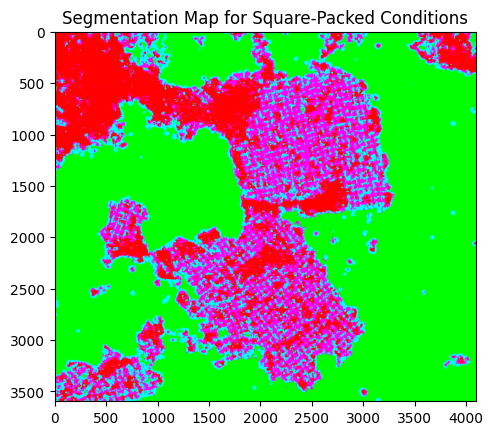

In [7]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import matplotlib.patches as mpatches

# Load the trained segmentation model
# model = SegmentationModel(num_classes=4)  # Ensure num_classes matches your model
# model.load_state_dict(torch.load("path/to/your/trained_model.pth"))  # Update with your model path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
model.to(device)
model.eval()

# Define transformation
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Path for the TIFF image
image_path = "36kImages/36000 x 1749 Ceta.tif"

# Load and preprocess the image
image = Image.open(image_path).convert("RGB")
# Crop the image to remove the bottom 500 pixels
width, height = image.size
image = image.crop((0, 0, width, height - 500))  # (left, upper, right, lower)

# Transform the cropped image into a tensor
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Predict the segmentation map
with torch.no_grad():
    output = model(input_tensor)  # Output shape: [1, num_classes, H, W]
    predicted_classes = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()  # Shape: [H, W]

# Define colormap for visualization
height, width = predicted_classes.shape
colormap = np.zeros((height, width, 3), dtype=np.uint8)

# Set colors for each class
class_colors = {
    0: (0, 255, 0),   # Background
    1: (0, 0, 255),   # Low Fill
    2: (255, 0, 0),   # Multilayer
    3: (0, 255, 255), # Single Hexagonal
    4: (255, 0, 255), # Single Square
}

# Fill the colormap
for class_label, color in class_colors.items():
    colormap[predicted_classes == class_label] = color

# Calculate percentages
total_pixels = height * width
class_counts = [np.sum(predicted_classes == label) for label in class_colors.keys()]
percentages = [(count / total_pixels) * 100 for count in class_counts]

# Print percentages
print(f"Background: {percentages[0]:.2f}%")
print(f"Low Fill: {percentages[1]:.2f}%")
print(f"Multilayer: {percentages[2]:.2f}%")
print(f"Single Hexagonal: {percentages[3]:.2f}%")
print(f"Single Square: {percentages[4]:.2f}%")


# Display the colormap
plt.imshow(colormap)
plt.title("Segmentation Map for Square-Packed Conditions")

# Define patches for each class with labels
background_patch = mpatches.Patch(color=(0, 1, 0), label='Background')  # Green
lowfill_patch = mpatches.Patch(color=(0, 0, 1), label='Low Fill')  # Blue
multilayer_patch = mpatches.Patch(color=(255, 0, 0), label='Multilayer')  # Red
single_hexagonal_patch = mpatches.Patch(color=(0, 255, 255), label='Single Hexagonal')  # Cyan
single_square_patch = mpatches.Patch(color=(255, 0, 255), label='Single Square')  # Magenta

# Add legend
plt.legend(handles=[background_patch, lowfill_patch, multilayer_patch, single_hexagonal_patch, single_square_patch], loc='upper right')

# Show the plot
plt.show()

In [5]:
def slide_inference(model, image_pil, patch_size=128, stride=64, transform=None, device=None, magnification=120):
    # Use 36 as baseline magnification
    scale_factor = magnification / 36.0
    adjusted_patch_size = int(scale_factor * patch_size)
    image_np = np.array(image_pil)
    H, W, _ = image_np.shape
    final_pred = np.zeros((H, W), dtype=np.uint8)

    for top in range(0, H - patch_size + 1, stride):
        for left in range(0, W - patch_size + 1, stride):
            # Extract a patch scaled by the magnification factor
            patch = image_np[top : top + adjusted_patch_size, left : left + adjusted_patch_size]
            patch_pil = Image.fromarray(patch)
            patch_pil = patch_pil.resize((patch_size, patch_size), Image.BILINEAR)

            patch_tensor = (transform(patch_pil) if transform 
                            else transforms.ToTensor()(patch_pil))
            patch_tensor = patch_tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(patch_tensor)
                pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
            final_pred[top : top + patch_size, left : left + patch_size] = pred

    return final_pred
import re

def extract_magnification(filename, default=120):
    match = re.search(r'(\d+)\s*(kx|x)', filename, re.IGNORECASE)
    if match:
        return int(match.group(1))
    return default

def process_images(image_folder, image_names, output_csv, model, transform, device):
    class_colors = {
        0: "Background",
        1: "Low Fill",
        2: "Multilayer",
        3: "Rods",
        4: "Single Hexagonal",
        5: "Single Square"
    }
    results = []
    for image_name in image_names:
        image_path = os.path.join(image_folder, image_name)
        image = Image.open(image_path).convert("RGB")
        # (Optional) crop if needed
        width, height = image.size
        image = image.crop((0, 0, width, height - 500))
        
        # Determine magnification from filename
        mag = extract_magnification(image_name, default=120)
        predicted_classes = slide_inference(
            model=model,
            image_pil=image,
            patch_size=128,
            stride=32,
            transform=transform,
            device=device,
            magnification=mag
        )
        # Compute percentages etc.
        h, w = predicted_classes.shape
        total_pixels = h * w
        percentages = {class_colors[k]: (np.sum(predicted_classes==k) / total_pixels * 100)
                       for k in class_colors}
        result = {"Image": image_name, **percentages}
        results.append(result)
        print(f"\nResults for {image_name}:")
        for label, pct in percentages.items():
            print(f"  {label}: {pct:.2f}%")
    # Save CSV etc.
    with open(output_csv, mode="w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=["Image"] + list(class_colors.values()))
        writer.writeheader()
        writer.writerows(results)
    return results
import os

# Define the directory and filter TIFF images
directory = "6H_AllPics"
if os.path.exists(directory) and os.path.isdir(directory):
    image_files = [f for f in os.listdir(directory) if f.lower().endswith('.tif')]
    print("\nFiles in 6H_AllPics:")
    for file in image_files:
        print(file)
else:
    print(f"Directory '{directory}' does not exist.")

# Now pass 'image_files' and the directory to your process_images function:
results = process_images(directory, image_files, "output.csv", model, transform, device)


Files in 6H_AllPics:
120 kx 1321 Ceta (1).tif
120 kx 1649 Ceta.tif
120 kx 1651 Ceta.tif
120 kx 1659 Ceta.tif
120 kx 1710 0001 Ceta.tif
120 kx 1710 0002 Ceta.tif
120 kx 1714 Ceta.tif
120 kx 20220218 Ceta Camera Ceta.tif
120 kx 20221111 Ceta.tif
120 kx 20221125 120 kx 0001 Ceta (1).tif
120 kx 20221125 120 kx 0001 Ceta.tif
120 kx.tif
120 kx20221125 120 kx 0002 Ceta.tif
120 kx20221125 120 kx Ceta.tif
36000 x 1410 Ceta.tif
36000 x 1646 Ceta.tif
36000 x 1648 Ceta.tif
36000 x 1652 Ceta (1).tif
36000 x 1713 Ceta.tif
46000 x 1625 Ceta (1).tif

Results for 120 kx 1321 Ceta (1).tif:
  Background: 66.77%
  Low Fill: 7.19%
  Multilayer: 7.64%
  Rods: 2.96%
  Single Hexagonal: 1.34%
  Single Square: 14.10%

Results for 120 kx 1649 Ceta.tif:
  Background: 27.32%
  Low Fill: 0.45%
  Multilayer: 10.93%
  Rods: 55.68%
  Single Hexagonal: 5.61%
  Single Square: 0.02%

Results for 120 kx 1651 Ceta.tif:
  Background: 10.86%
  Low Fill: 0.00%
  Multilayer: 1.81%
  Rods: 87.01%
  Single Hexagonal: 0.31%
  S

KeyboardInterrupt: 

Background: 51.43%
Low Fill: 0.00%
Multilayer: 8.89%
Rods: 0.00%
Single Hexagonal: 8.66%
Single Square: 31.03%


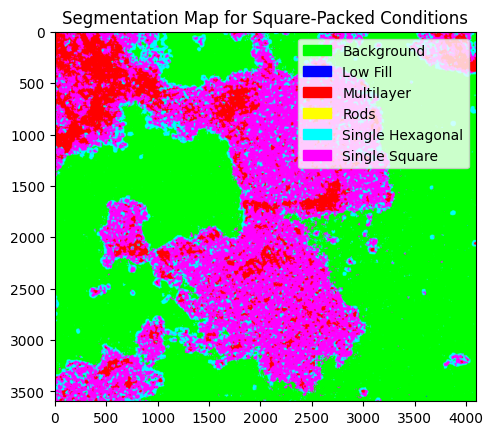

In [4]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import matplotlib.patches as mpatches

# Load the trained segmentation model
# model = SegmentationModel(num_classes=6)  # Update with your model class and correct num_classes
# model.load_state_dict(torch.load("path/to/your/trained_model.pth", map_location="cuda" if torch.cuda.is_available() else "cpu"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Define transformation
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Path for the TIFF image
image_path = "36kImages/36000 x 1749 Ceta.tif"

# Load and preprocess the image
image = Image.open(image_path).convert("RGB")
width, height = image.size
image = image.crop((0, 0, width, height - 500))

# Transform the cropped image into a tensor
input_tensor = transform(image).unsqueeze(0).to(device)

# Predict the segmentation map
with torch.no_grad():
    output = model(input_tensor)  # [1, num_classes, H, W]
    predicted_classes = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# Define colormap
height, width = predicted_classes.shape
colormap = np.zeros((height, width, 3), dtype=np.uint8)

# Set colors for each class
class_colors = {
    0: (0, 255, 0),   # Background
    1: (0, 0, 255),   # Low Fill
    2: (255, 0, 0),   # Multilayer
    3: (255, 255, 0), # Rods
    4: (0, 255, 255), # Single Hexagonal
    5: (255, 0, 255), # Single Square
}

for class_label, color in class_colors.items():
    colormap[predicted_classes == class_label] = color

# Calculate percentages
total_pixels = height * width
class_counts = [np.sum(predicted_classes == label) for label in class_colors.keys()]
percentages = [(count / total_pixels) * 100 for count in class_counts]

# Print percentages
print(f"Background: {percentages[0]:.2f}%")
print(f"Low Fill: {percentages[1]:.2f}%")
print(f"Multilayer: {percentages[2]:.2f}%")
print(f"Rods: {percentages[3]:.2f}%")
print(f"Single Hexagonal: {percentages[4]:.2f}%")
print(f"Single Square: {percentages[5]:.2f}%")

# Display colormap
plt.imshow(colormap)
plt.title("Segmentation Map for Square-Packed Conditions")

# Define legend patches
legend_patches = [
    mpatches.Patch(color=np.array(color)/255.0, label=label)
    for label, color in zip(
        ['Background', 'Low Fill', 'Multilayer', 'Rods', 'Single Hexagonal', 'Single Square'],
        [class_colors[i] for i in range(6)]
    )
]

plt.legend(handles=legend_patches, loc='upper right')
plt.show()


In [ ]:
# Save the model checkpoint
checkpoint_path = "segmentation_model_checkpoint.pth"
torch.save(model.state_dict(), checkpoint_path)
print(f"Model checkpoint saved at {checkpoint_path}")

# Load the model checkpoint
model.load_state_dict(torch.load(checkpoint_path))
print("Model checkpoint loaded successfully") 

Clustering

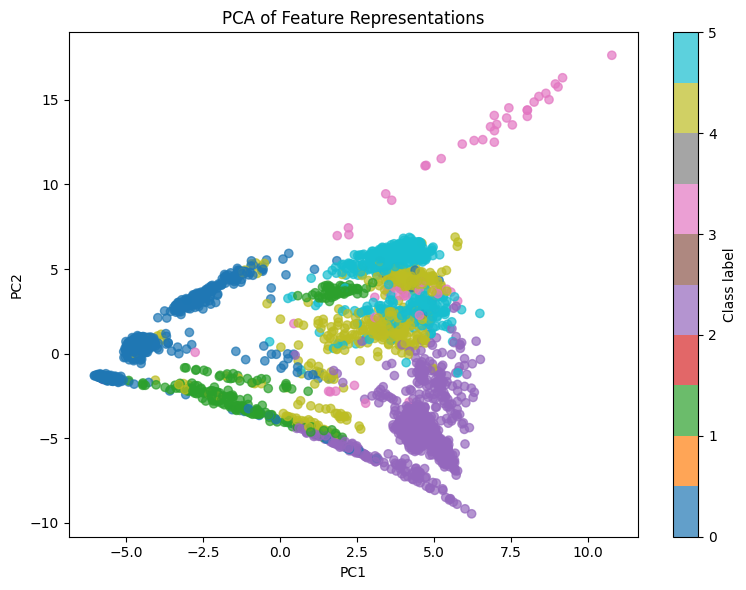

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Set model to eval
model.eval()
model.cuda()

features = []
labels = []

with torch.no_grad():
    for images, masks in train_loader:
        images = images.cuda()
        masks = masks.cuda()

        # Extract feature maps
        fmap = model.model.extract_features(images)  # Shape: (B, C, H, W)

        # Global average pool to reduce spatial dims
        pooled = torch.mean(fmap, dim=(2, 3))  # Shape: (B, C)

        features.append(pooled.cpu())
        labels.append(masks.view(masks.size(0), -1).mode(1)[0].cpu())  # Majority label per image

features = torch.cat(features).numpy()
labels = torch.cat(labels).numpy()

# PCA
pca = PCA(n_components=2)
proj = pca.fit_transform(features)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(proj[:, 0], proj[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label="Class label")
plt.title("PCA of Feature Representations")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


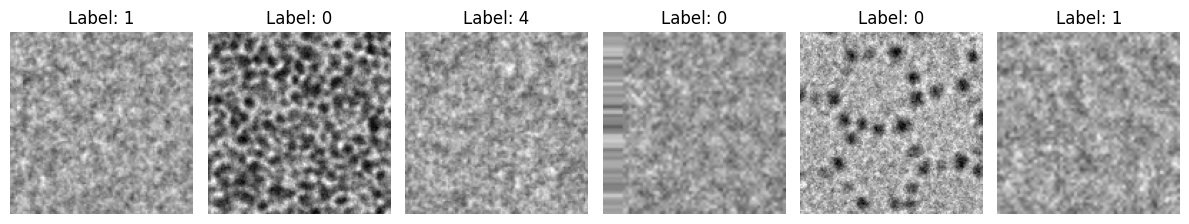

In [16]:
from scipy.spatial.distance import cdist
import numpy as np

# Compute pairwise distances
dists = cdist(proj, proj, metric='euclidean')

# Mask same-label pairs
label_array = labels.reshape(-1, 1)
label_mask = (label_array == label_array.T)

# Set distance to inf if labels match or same index
np.fill_diagonal(dists, np.inf)
dists[label_mask] = np.inf

# Find top-N closest mismatched-label pairs
num_samples = 3
pairs = []
for _ in range(num_samples):
    i, j = np.unravel_index(np.argmin(dists), dists.shape)
    pairs.append((i, j))
    dists[i, j] = np.inf  # prevent reselecting
    dists[j, i] = np.inf

# Unique indices of the mismatched close samples
idxs = list(set([i for i, j in pairs] + [j for i, j in pairs]))
fig, axes = plt.subplots(1, len(idxs), figsize=(12, 4))
for ax, idx in zip(axes, idxs):
    img_path = os.path.join(train_dataset.image_dir, train_dataset.image_paths[idx])
    img = Image.open(img_path).resize((128, 128))
    ax.imshow(img)
    ax.set_title(f"Label: {labels[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()
